In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import random
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f"Using device: {device}")

WORDS    = ['one','two','three','four','five','six','seven','eight','nine','ten']
PAD = '<PAD>'
SOS = '<SOS>'
EOS = '<EOS>'

vocab = [PAD, SOS, EOS] + WORDS
word2idx = {w:i for i,w in enumerate(vocab)}
idx2word = {i:w for w,i in word2idx.items()}

VOCAB_SIZE = len(vocab)
PAD_IDX    = word2idx[PAD]
SOS_IDX    = word2idx[SOS]
EOS_IDX    = word2idx[EOS]

print(f"Vocabulary size: {VOCAB_SIZE}")
print(f"Vocab: {vocab}")

def make_pair(seq_len = None):
    if seq_len is None:
        seq_len = random.randint(3,6)
    words = random.sample(WORDS, seq_len)
    src = [word2idx[w] for w in words]
    tgt = [SOS_IDX] + [word2idx[w] for w in reversed(words)] + [EOS_IDX]
    return src, tgt 

def collate_fn(batch):
    srcs, tgts = zip(*batch)
    src_lens = [len(s) for s in srcs]
    tgt_lens = [len(t) for t in tgts]

    max_src = max(src_lens)
    max_tgt = max(tgt_lens)

    srcs_padded = torch.tensor(
        [s + [PAD_IDX] * (max_src - len(s)) for s in srcs]
    )

    tgts_padded = torch.tensor(
        [t + [PAD_IDX] * (max_tgt - len(t)) for t in tgts]
    )

    return srcs_padded, tgts_padded

class ReversalDataset(Dataset):
    def __init__(self, n_samples):
        self.pairs = [make_pair() for _ in range(n_samples)]

    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        return self.pairs[idx]

dataset = ReversalDataset(5000)
dataloader = DataLoader( dataset, batch_size=64, shuffle = True, collate_fn=collate_fn)

# Sanity check
src_sample, tgt_sample = make_pair(4)
print(f"\nSample pair:")
print(f"  Source: {[idx2word[i] for i in src_sample]}")
print(f"  Target: {[idx2word[i] for i in tgt_sample]}")


Using device: mps
Vocabulary size: 13
Vocab: ['<PAD>', '<SOS>', '<EOS>', 'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine', 'ten']

Sample pair:
  Source: ['nine', 'five', 'eight', 'three']
  Target: ['<SOS>', 'three', 'eight', 'five', 'nine', '<EOS>']


In [13]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx= PAD_IDX)
        self.lstm = nn.LSTM(
            embed_size, hidden_size, num_layers,
            batch_first = True,
            dropout = dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        outputs, (h_n, c_n) = self.lstm(embedded)
        return h_n, c_n 

class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx= PAD_IDX)
        self.lstm = nn.LSTM(
            embed_size, hidden_size, num_layers,
            batch_first = True,
            dropout = dropout if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, token, h, c):
        token = token.unsqueeze(1)
        embedded = self.dropout(self.embedding(token))
        output, (h, c) = self.lstm(embedded, (h, c))
        prediction = self.fc(output.squeeze(1)) 
        return prediction, h, c 

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
    
    def forward (self, src, tgt, teacher_forcing_ratio = 0.5):
        batch_size = src.shape[0]
        tgt_len = tgt.shape[1]

        outputs = torch.zeros(batch_size, tgt_len, VOCAB_SIZE).to(device)

        h, c = self.encoder(src)

        dec_input = tgt[:,0]                            # (batch,)

        for t in range(1, tgt_len):
            pred, h, c = self.decoder(dec_input, h, c)
            outputs[:, t, :] = pred

            # Teacher forcing 
            use_teacher = random.random() < teacher_forcing_ratio
            dec_input   = tgt[:, t] if use_teacher else pred.argmax(dim=1)
        
        return outputs

In [24]:
# Training 

EMBED_SIZE  = 64
HIDDEN_SIZE = 128
NUM_LAYERS  = 2
DROPOUT     = 0.3
EPOCHS      = 50
LR          = 0.001

encoder = Encoder(VOCAB_SIZE, EMBED_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(device)
decoder = Decoder(VOCAB_SIZE, EMBED_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(device)
model   = Seq2Seq(encoder, decoder).to(device)

# Counting parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")

optimizer = optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)  # ignore PAD in loss

train_losses = []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0

    for src_batch, tgt_batch in dataloader:
        src_batch = src_batch.to(device)
        tgt_batch = tgt_batch.to(device)

        optimizer.zero_grad()
        output = model(src_batch, tgt_batch, teacher_forcing_ratio=0.5)
        
        # Reshaping for CrossEntropyLoss
        output_flat = output[:, 1:, :].reshape(-1, VOCAB_SIZE)
        tgt_flat    = tgt_batch[:, 1:].reshape(-1)

        loss = criterion(output_flat, tgt_flat)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        epoch_loss += loss.item()
    
    avg_loss = epoch_loss/len(dataloader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Loss: {avg_loss:.4f}")




Total trainable parameters: 466,189
Epoch 01/50 | Loss: 1.8037
Epoch 02/50 | Loss: 1.0451
Epoch 03/50 | Loss: 0.5832
Epoch 04/50 | Loss: 0.3449
Epoch 05/50 | Loss: 0.2146
Epoch 06/50 | Loss: 0.1483
Epoch 07/50 | Loss: 0.1004
Epoch 08/50 | Loss: 0.0749
Epoch 09/50 | Loss: 0.0576
Epoch 10/50 | Loss: 0.0574
Epoch 11/50 | Loss: 0.0366
Epoch 12/50 | Loss: 0.0306
Epoch 13/50 | Loss: 0.0265
Epoch 14/50 | Loss: 0.0200
Epoch 15/50 | Loss: 0.0185
Epoch 16/50 | Loss: 0.0167
Epoch 17/50 | Loss: 0.0154
Epoch 18/50 | Loss: 0.0123
Epoch 19/50 | Loss: 0.0111
Epoch 20/50 | Loss: 0.0120
Epoch 21/50 | Loss: 0.0115
Epoch 22/50 | Loss: 0.0147
Epoch 23/50 | Loss: 0.0091
Epoch 24/50 | Loss: 0.0087
Epoch 25/50 | Loss: 0.0065
Epoch 26/50 | Loss: 0.0064
Epoch 27/50 | Loss: 0.0058
Epoch 28/50 | Loss: 0.0052
Epoch 29/50 | Loss: 0.0047
Epoch 30/50 | Loss: 0.0047
Epoch 31/50 | Loss: 0.0070
Epoch 32/50 | Loss: 0.0134
Epoch 33/50 | Loss: 0.0064
Epoch 34/50 | Loss: 0.0043
Epoch 35/50 | Loss: 0.0049
Epoch 36/50 | Loss

In [25]:
def translate(model, src_words, max_len=10):
    model.eval()
    with torch.no_grad():
        src = torch.tensor([[word2idx[w] for w in src_words]]).to(device)
        h, c = model.encoder(src)

        dec_input = torch.tensor([SOS_IDX]).to(device)
        result    = []

        for _ in range(max_len):
            pred, h, c = model.decoder(dec_input, h, c)
            top_token   = pred.argmax(dim=1)
            word        = idx2word[top_token.item()]

            if word == EOS:
                break
            result.append(word)
            dec_input = top_token

    return result

test_cases = [
    ['one', 'two', 'three'],
    ['five', 'nine', 'two', 'seven'],
    ['ten', 'four', 'six', 'one', 'eight'],
]

for src_words in test_cases:
    predicted = translate(model, src_words)
    expected  = list(reversed(src_words))
    correct   = "✅" if predicted == expected else "❌"
    print(f"  Input:    {src_words}")
    print(f"  Expected: {expected}")
    print(f"  Got:      {predicted}  {correct}")
    print()


  Input:    ['one', 'two', 'three']
  Expected: ['three', 'two', 'one']
  Got:      ['three', 'two', 'one']  ✅

  Input:    ['five', 'nine', 'two', 'seven']
  Expected: ['seven', 'two', 'nine', 'five']
  Got:      ['seven', 'two', 'nine', 'five']  ✅

  Input:    ['ten', 'four', 'six', 'one', 'eight']
  Expected: ['eight', 'one', 'six', 'four', 'ten']
  Got:      ['eight', 'one', 'six', 'four', 'ten']  ✅



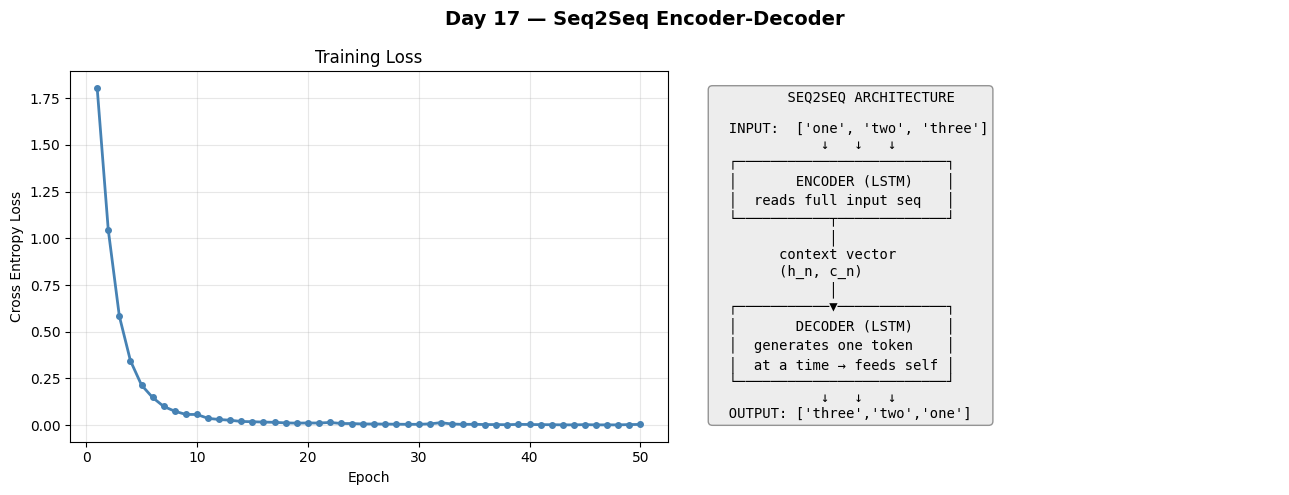

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Day 17 — Seq2Seq Encoder-Decoder', fontsize=14, fontweight='bold')

# Plot 1: Training loss
axes[0].plot(range(1, EPOCHS + 1), train_losses, color='steelblue', linewidth=2, marker='o', markersize=4)
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross Entropy Loss')
axes[0].grid(True, alpha=0.3)

axes[1].axis('off')
diagram = (
    "         SEQ2SEQ ARCHITECTURE\n\n"
    "  INPUT:  ['one', 'two', 'three']\n"
    "             ↓   ↓   ↓\n"
    "  ┌─────────────────────────┐\n"
    "  │       ENCODER (LSTM)    │\n"
    "  │  reads full input seq   │\n"
    "  └───────────┬─────────────┘\n"
    "              │\n"
    "        context vector\n"
    "        (h_n, c_n)\n"
    "              │\n"
    "  ┌───────────▼─────────────┐\n"
    "  │       DECODER (LSTM)    │\n"
    "  │  generates one token    │\n"
    "  │  at a time → feeds self │\n"
    "  └─────────────────────────┘\n"
    "             ↓   ↓   ↓\n"
    "  OUTPUT: ['three','two','one']"
)
axes[1].text(0.05, 0.95, diagram, transform=axes[1].transAxes,
             fontsize=10, verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.4))

plt.tight_layout()
plt.savefig('day17_seq2seq.png', dpi=150, bbox_inches='tight')
plt.show()